In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
df=pd.read_csv("smartcart_customers.csv")

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [16]:
df.shape

(2240, 22)

In [18]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocessing

# Handling Missing Values

In [23]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [25]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## feature eng.

In [42]:
#Age
df["Age"]=2026-df["Year_Birth"]

In [44]:
#Customer joining date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days


In [38]:
#spending
df["Total_Spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [40]:
#children
df["Total_children"]=df["Kidhome"]+df["Teenhome"]

In [54]:
#Education

df["Education"]=df["Education"].replace({
   "Basic":"Undergraduate",
    "2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate",
    "PhD":"Postgraduate"    
})

In [58]:
#marital status

df["Living_With"]=df["Marital_Status"].replace({
   "Married":"Partner",
    "Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Absurd":"Alone",
    "YOLO":"Alone"
})

In [60]:
df["Living_With"].value_counts()


Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [64]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


## Drop Columns

In [72]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer","MntWines","MntFruits","MntMeatProducts","MntSweetProducts","MntGoldProds","MntFishProducts"]

In [74]:
df_cleaned = df.drop(cols, axis=1)


In [76]:
df_cleaned.shape

(2240, 15)

## Outliers

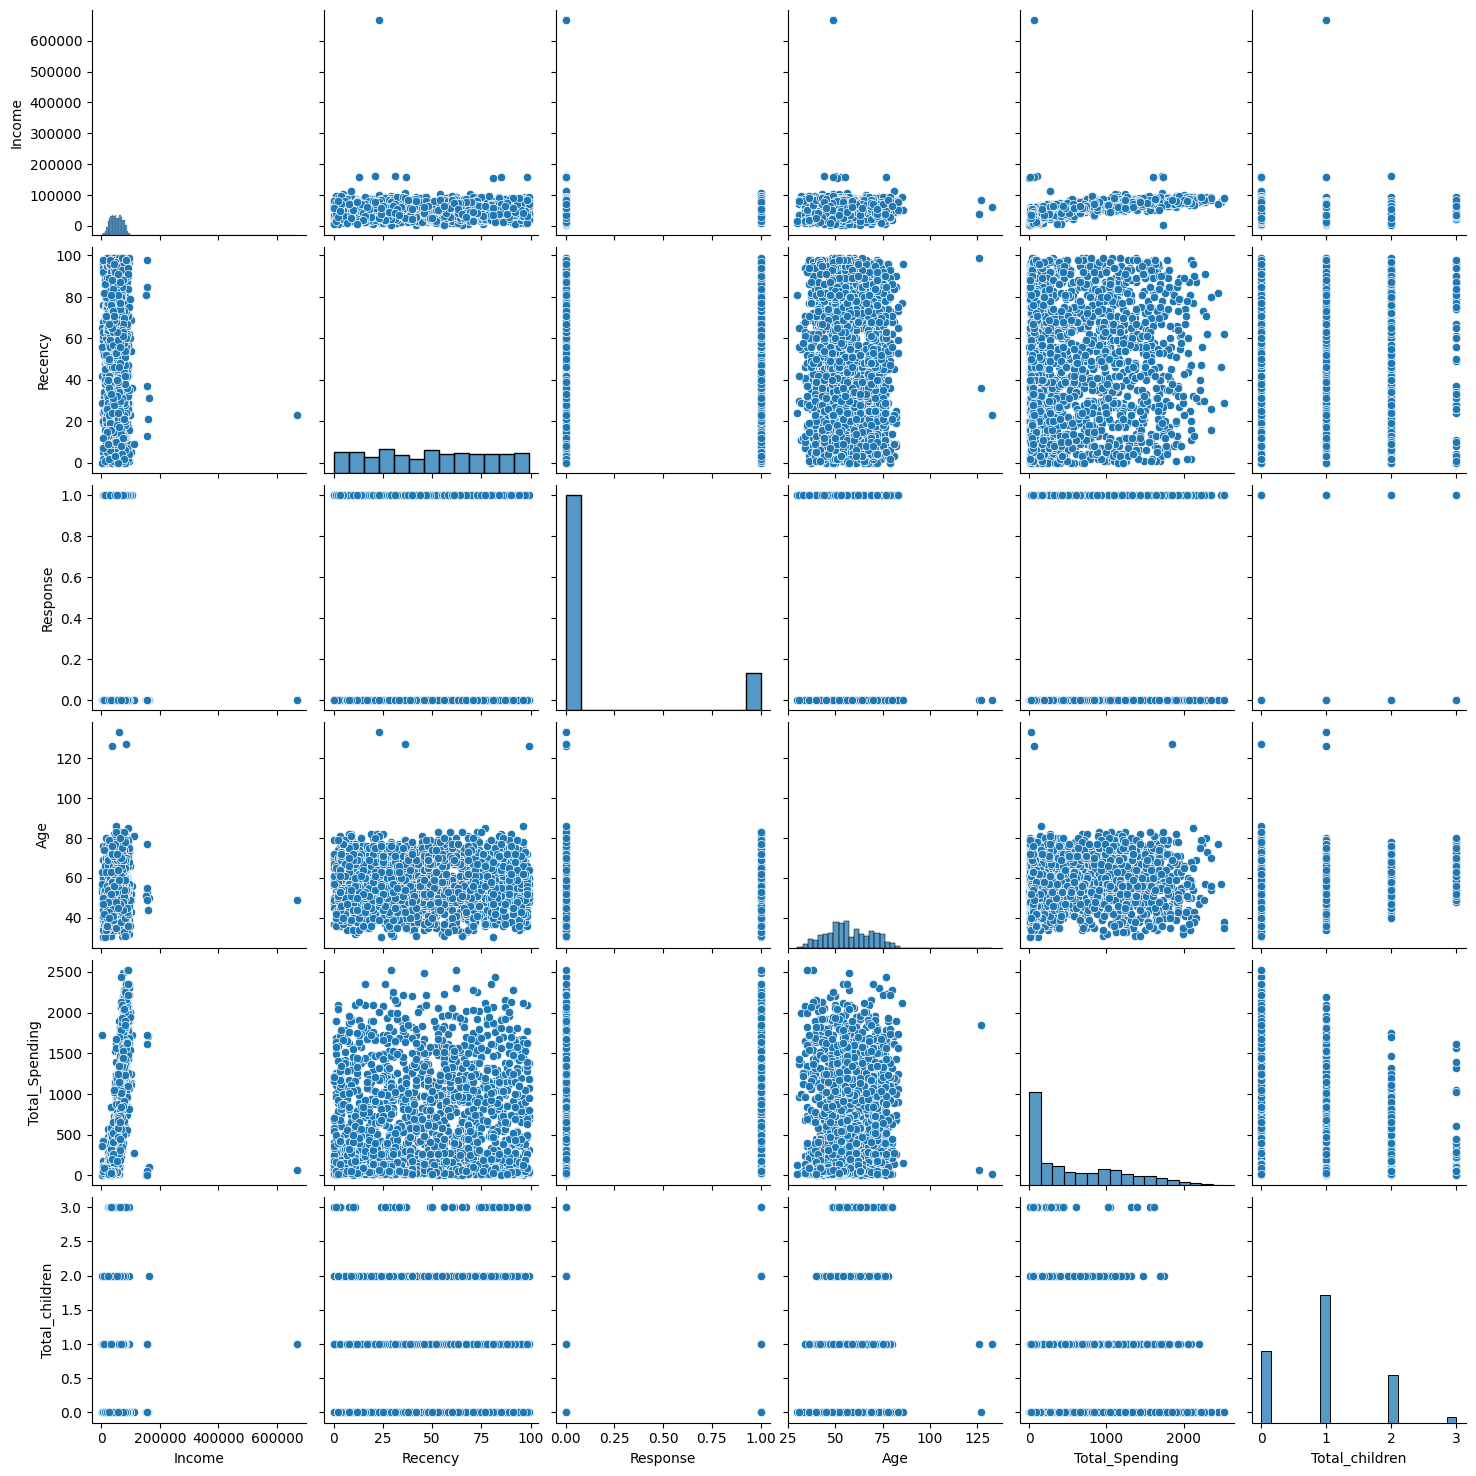

In [81]:
cols=["Income","Recency","Response","Age","Total_Spending","Total_children"]

sns.pairplot(df_cleaned[cols])

In [85]:
#remove outliers

print("Data size with outliers",len(df_cleaned))

df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600000)]

print("data size without outliers",len(df_cleaned))


Data size with outliers 2240
data size without outliers 2236


## Heatmap

In [88]:
corr=df_cleaned.corr(numeric_only=True)


<Axes: >

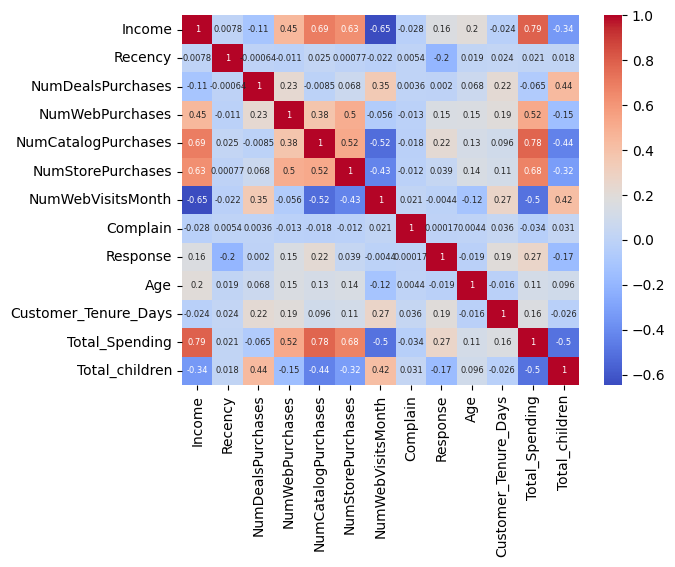

In [96]:
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

## Encoding

In [105]:
from sklearn.preprocessing import OneHotEncoder

ohe=OneHotEncoder()

cat_cols=["Education","Living_With"]

enc_cols=ohe.fit_transform(df_cleaned[cat_cols])
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [109]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [115]:
df_encoded.shape

(2236, 18)

## Scaling

In [118]:
from sklearn.preprocessing import StandardScaler

In [120]:
X=df_encoded

In [122]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

## Visualize

In [125]:
#2D

from  sklearn.decomposition import PCA

In [149]:
pca=PCA(n_components=3)

x_pca=pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3D projection')

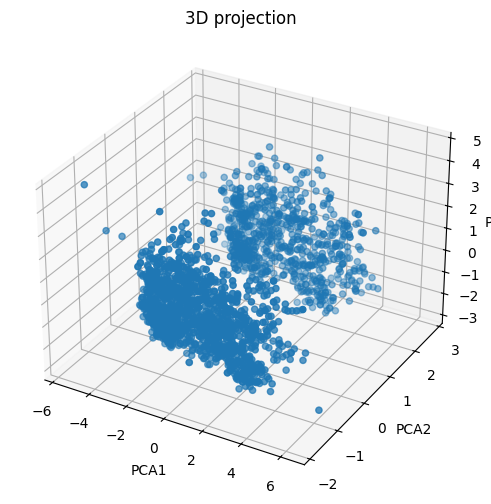

In [159]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")


In [161]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

# Analyze K value

## 1.Elbow Method

In [173]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [177]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow

In [179]:
print("best k:",optimal_k)

best k: 4


Text(0, 0.5, 'wcss')

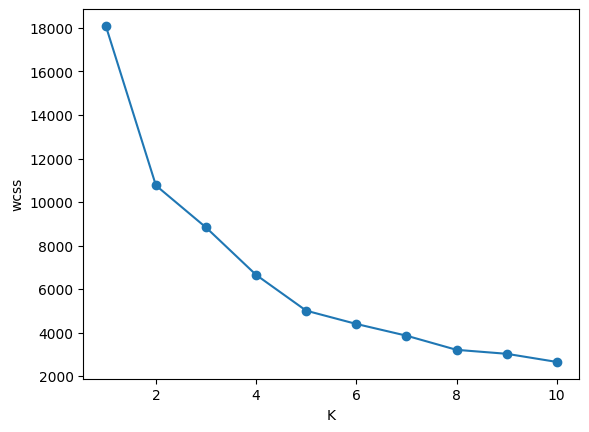

In [183]:
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K")
plt.ylabel("wcss")

## 2. Silhouette score

Text(0, 0.5, 'scores')

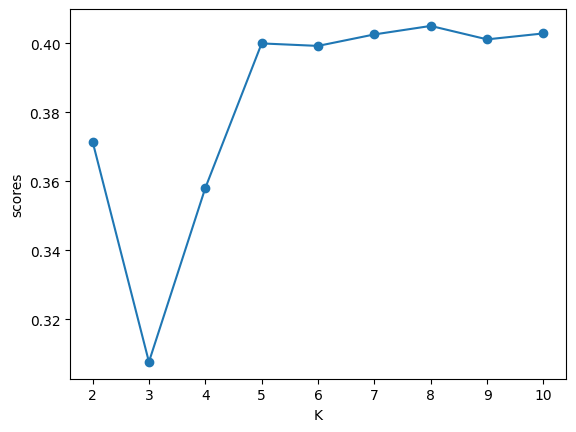

In [194]:
from sklearn.metrics import silhouette_score

scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(x_pca)
    score=silhouette_score(x_pca,labels)
    scores.append(score)

plt.plot(range(2,11),scores,marker='o')
plt.xlabel("K")
plt.ylabel("scores")

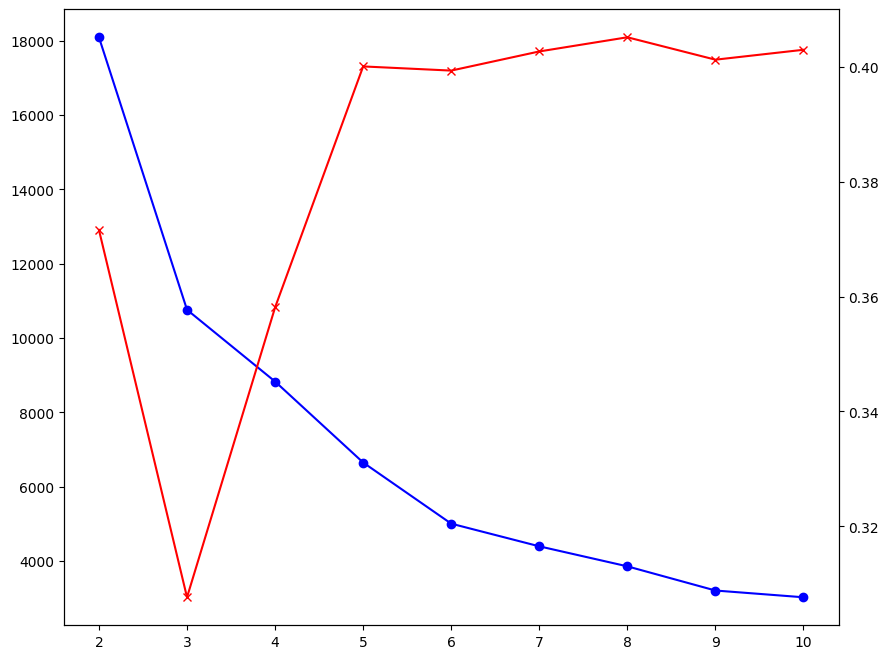

In [212]:
#combined plot
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(10,8))


ax1.plot(k_range,wcss[:len(k_range)],marker='o',color="blue")

ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker='x',color="red")

# clustering

In [215]:
kmeans=KMeans(n_clusters=4,random_state=42)
labels=kmeans.fit_predict(x_pca)

Text(0.5, 0.92, '3D projection')

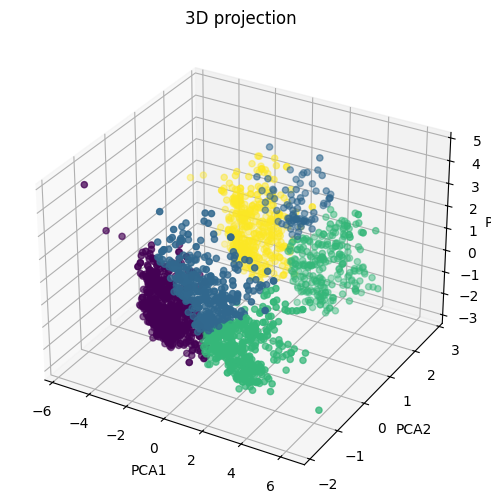

In [217]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")


In [221]:
# Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering

agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")

label_agg=agg_clf.fit_predict(x_pca)


Text(0.5, 0.92, '3D projection')

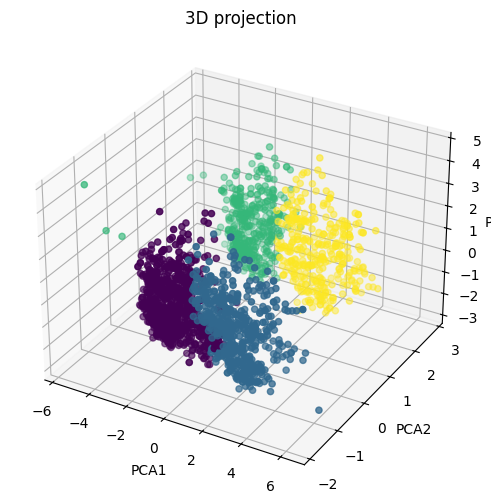

In [223]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=label_agg)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")


# Charaterization of Clusters

In [242]:
X["cluster"]=label_agg


<Axes: xlabel='cluster', ylabel='count'>

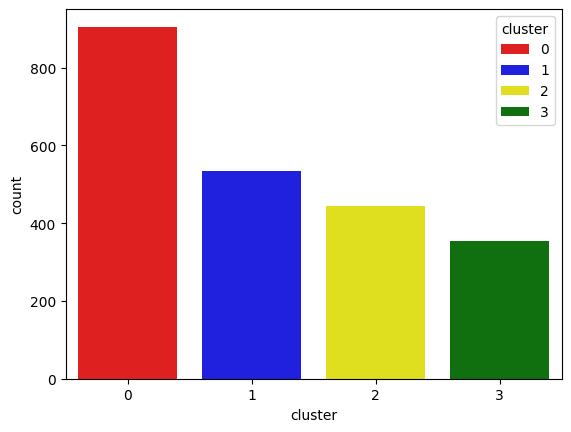

In [244]:
pal=["red","blue","yellow","green"]

sns.countplot(x=X["cluster"],palette=pal,hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

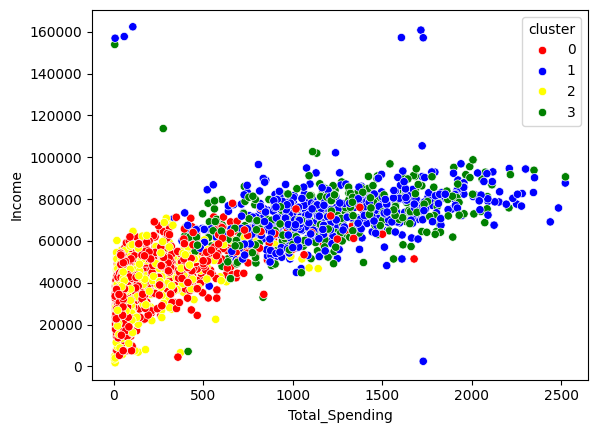

In [246]:
#Income & spending relation
sns.scatterplot(
    x=X["Total_Spending"],
    y=X["Income"],
    hue=X["cluster"],
    palette=pal
)

In [248]:
#cluster summary

cluster_summary=X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         